# Mietpreis-Vorhersage Schweiz – Saubere ML-Pipeline (v3)

Dieses Notebook ist eine bereinigte Version von `model_v2.ipynb`. Die wichtigsten Änderungen:

- **Ein einziger, sauberer Train/Eval-Split.** Kein `concat → head/tail`-Recovery, kein `fit_transform` auf kombinierten Train+Eval-Daten.
- **Pipelines** für lineare Modelle, damit Skalierung *innerhalb* der Cross-Validation passiert (kein Leakage).
- **Zentrale Feature-Sets** (`FEATURES_SMALL`, `FEATURES_ALL`, `FEATURES_ENGINEERED`) – Training, Evaluation und Final Prediction nutzen exakt dieselbe Spaltenliste in derselben Reihenfolge.
- **Korrekte Metriken**: `np.sqrt(mean_squared_error(...))` statt `squared=False`, `median_absolute_error` ohne fälschliches `np.sqrt(...)`.
- **Fehleranalyse** nach Preisgruppen, Overfitting-Diagnose, optionaler Group-Split.

## Inhalt

1. Setup & Imports
2. Daten laden
3. Spalten umbenennen
4. Datenqualität prüfen
5. Duplikate und Ausreißer analysieren
6. Feature Engineering
7. Feature-Sets zentral definieren
8. Sauberer Train/Eval-Split
9. Modell-Pipelines definieren
10. Modelle fair vergleichen
11. Train-vs-Eval-Metriken (Visualisierung)
12. Overfitting-Diagnose
13. Cross-Validation
14. Visualisierungen (Actual vs Predicted)
    - 14b. Prediction Curves – Vergleich der Vorhersagekurven
    - 14c. Demo: Underfitting / Good Fit / Overfitting
15. Residual Analysis
16. Fehleranalyse nach Preisgruppen
17. Feature Importance
18. Bestes Modell auswählen
19. Finale Prediction (mit Spaltencheck)
20. Optional: Group Split nach Koordinaten
21. Geo-Analyse und Geo-Clustering
    - 21.1 Geo-Spalten prüfen
    - 21.2 Geo-EDA (Scatter colored by price / price_per_sqm)
    - 21.3 KMeans Clustering – verschiedene Clusterzahlen testen
    - 21.4 Cluster visualisieren & Preisstatistik
    - 21.5 Modellvergleich: ohne vs. mit Geo-Cluster
    - 21.6 Optional: Elevation ins Clustering aufnehmen
    - 21.7 Lineare Modelle mit OneHotEncoded geo_cluster
    - 21.8 Optional: DBSCAN (Analyse-only)
    - 21.9 Geo-Prediction-Kurve entlang `east`
    - 21.10 Zusammenfassung Geo

## 1. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score, GroupShuffleSplit
)
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error,
    median_absolute_error, r2_score
)
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Optional Boosting libraries — Notebook läuft auch ohne diese.
try:
    from xgboost import XGBRegressor
    HAS_XGB = True
except ImportError:
    HAS_XGB = False

try:
    from lightgbm import LGBMRegressor
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False

RANDOM_STATE = 42
TEST_SIZE    = 0.2

print(f'XGBoost verfügbar : {HAS_XGB}')
print(f'LightGBM verfügbar: {HAS_LGBM}')

XGBoost verfügbar : True
LightGBM verfügbar: True


## 2. Daten laden

Wir laden den vollständigen Datensatz **einmal** und splitten erst später. Damit ist sichergestellt, dass dieselbe Stichprobe konsistent durch das Notebook läuft und kein versehentliches Re-Splitten oder Recovery via `head/tail` möglich ist.

In [2]:
DATA_PATH = '../external-sources/output_csv/model.csv'

df_raw = pd.read_csv(DATA_PATH)
print(f'Geladen: {df_raw.shape[0]} Zeilen × {df_raw.shape[1]} Spalten')
df_raw.head()

Geladen: 4536 Zeilen × 12 Spalten


,area_sqm,rooms,price_cold,population,oev_score,solar_class,elevation_m,lv95_east,lv95_north,gbauj,ganzwhg,garea
0,34,2,850,44,2043.0,2.0,572.9,2687446.25,1248599.000,1971,1,192.0
1,108,4,1990,107,5656.0,3.0,672.3,2642156.00,1130267.625,1974,34,2000.0
2,97,4,1520,184,12617.0,4.0,439.6,2597233.25,1226600.375,2017,18,367.0
3,23,1,1396,129,18439.0,4.0,430.4,2532786.25,1155625.250,1948,50,731.0
4,76,3,1400,48,717.0,3.0,743.6,2583429.75,1231621.000,2018,17,587.0


## 3. Spalten umbenennen

Sprechende, kurze Namen. Das Mapping ist explizit, damit klar ist, welche Quellspalte wohin geht.

In [3]:
column_renames = {
    'area_sqm':    'area',
    'rooms':       'rooms',
    'price_cold':  'price',
    'population':  'population',
    'oev_score':   'oev',
    'solar_class': 'solar',
    'elevation_m': 'elevation',
    'lv95_east':   'east',
    'lv95_north':  'north',
    'gbauj':       'year_built',
    'ganzwhg':     'apartments',
    'garea':       'land_area',
}

df = df_raw.rename(columns=column_renames).copy()
print('Spalten nach Rename:', df.columns.tolist())

Spalten nach Rename: ['area', 'rooms', 'price', 'population', 'oev', 'solar', 'elevation', 'east', 'north', 'year_built', 'apartments', 'land_area']


## 4. Datenqualität prüfen

In [4]:
print('Shape:', df.shape)
df.info()

Shape: (4536, 12)
<class 'pandas.DataFrame'>
RangeIndex: 4536 entries, 0 to 4535
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   area        4536 non-null   int64  
 1   rooms       4536 non-null   int64  
 2   price       4536 non-null   int64  
 3   population  4536 non-null   int64  
 4   oev         4536 non-null   float64
 5   solar       4536 non-null   float64
 6   elevation   4536 non-null   float64
 7   east        4536 non-null   float64
 8   north       4536 non-null   float64
 9   year_built  4536 non-null   int64  
 10  apartments  4536 non-null   int64  
 11  land_area   4536 non-null   float64
dtypes: float64(6), int64(6)
memory usage: 425.4 KB


In [5]:
print('Fehlende Werte je Spalte:')
print(df.isna().sum())
print()
print('Duplikate (komplette Zeilen):', df.duplicated().sum())

Fehlende Werte je Spalte:
area          0
rooms         0
price         0
population    0
oev           0
solar         0
elevation     0
east          0
north         0
year_built    0
apartments    0
land_area     0
dtype: int64

Duplikate (komplette Zeilen): 325


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
area,4536.0,7.752403e+01,32.103016,1.00,5.600000e+01,76.000,9.500000e+01,324.0
rooms,4536.0,2.802249e+00,1.102830,1.00,2.000000e+00,3.000,4.000000e+00,15.0
price,4536.0,1.816199e+03,732.310694,130.00,1.345000e+03,1680.000,2.130000e+03,7700.0
population,4536.0,1.090999e+02,82.577927,3.00,4.900000e+01,90.000,1.440000e+02,602.0
oev,4536.0,9.986069e+03,14960.307365,0.00,1.800000e+03,4911.500,1.154900e+04,135157.0
solar,4536.0,3.092372e+00,1.015459,1.00,2.000000e+00,3.000,4.000000e+00,5.0
elevation,4536.0,4.624071e+02,158.817656,197.70,3.915000e+02,435.600,5.170000e+02,1570.7
east,4536.0,2.640999e+06,69270.961596,2494493.75,2.596506e+06,2645843.625,2.690937e+06,2818550.0
north,4536.0,1.218718e+06,52055.722323,1076962.00,1.178774e+06,1244662.000,1.258623e+06,1286728.5
year_built,4536.0,1.968925e+03,55.641365,1187.00,1.953000e+03,1974.000,2.010000e+03,2026.0


## 5. Duplikate und Ausreißer analysieren

`price_per_sqm` ist eine **Analyse-Größe**, kein Modellfeature: sie enthält das Target und würde zu Target Leakage führen.

In [7]:
TARGET_COL = 'price'

# Vorläufige Feature-Liste für die Duplikatsprüfung – wird in Kapitel 7 sauber finalisiert.
_features_for_dup_check = [
    'east', 'north', 'elevation', 'area', 'rooms', 'year_built',
    'apartments', 'land_area', 'population', 'oev', 'solar'
]

print('Duplikate gesamt          :', df.duplicated().sum())
print('Duplikate Features+Target :', df.duplicated(subset=_features_for_dup_check + [TARGET_COL]).sum())
print('Duplikate nur Features    :', df.duplicated(subset=_features_for_dup_check).sum())

Duplikate gesamt          : 325
Duplikate Features+Target : 325
Duplikate nur Features    : 562


In [8]:
# price_per_sqm NUR für Analyse — explizit nicht als Feature.
df['price_per_sqm'] = df['price'] / df['area']

print('Top 20 nach price_per_sqm (sehr teuer pro m²):')
df.sort_values('price_per_sqm', ascending=False).head(20)

Top 20 nach price_per_sqm (sehr teuer pro m²):


,area,rooms,price,population,oev,solar,elevation,east,north,year_built,apartments,land_area,price_per_sqm
3337,1,6,2500,13,225.0,2.0,668.5,2539457.75,1171911.250,2007,1,266.0,2500.000000
3213,1,4,2050,3,916.0,2.0,450.7,2536852.00,1183189.125,1895,1,70.0,2050.000000
427,1,3,1650,64,1691.0,5.0,625.3,2558554.00,1145940.125,1970,12,298.0,1650.000000
2019,1,3,1370,143,2077.0,4.0,450.7,2561697.25,1185393.375,1965,27,402.0,1370.000000
3137,1,3,1370,205,2077.0,1.0,450.9,2561732.00,1185383.000,1910,2,157.0,1370.000000
3068,1,2,1250,123,30274.0,5.0,413.9,2533764.75,1154087.375,1962,54,561.0,1250.000000
422,1,3,900,77,1087.0,4.0,412.5,2594891.25,1245585.625,1979,11,322.0,900.000000
2746,1,3,900,77,1087.0,4.0,412.5,2594891.25,1245585.625,1979,11,322.0,900.000000
71,1,2,860,95,12866.0,1.0,671.2,2746200.00,1254470.125,1918,9,1117.0,860.000000
2904,18,1,2500,231,96716.0,4.0,412.8,2681354.50,1247688.625,1909,41,208.0,138.888889


In [9]:
print('Bottom 20 nach price_per_sqm (sehr billig pro m²):')
df.sort_values('price_per_sqm', ascending=True).head(20)

Bottom 20 nach price_per_sqm (sehr billig pro m²):


,area,rooms,price,population,oev,solar,elevation,east,north,year_built,apartments,land_area,price_per_sqm
1444,105,4,200,177,15495.0,3.0,257.4,2611991.75,1267862.875,1891,2,258.0,1.904762
3543,110,3,258,147,1251.0,2.0,443.5,2676175.25,1214992.000,2005,3,101.0,2.345455
411,84,4,245,125,539.0,3.0,565.2,2722051.75,1258093.875,1964,9,313.0,2.916667
553,100,4,300,44,7811.0,2.0,395.5,2690300.75,1283502.125,1926,5,280.0,3.000000
86,100,4,300,44,7811.0,2.0,395.5,2690300.75,1283502.125,1926,5,280.0,3.000000
188,40,2,130,46,12414.0,3.0,727.3,2746243.75,1255577.375,1964,1,159.0,3.250000
2422,300,4,1225,94,2430.0,3.0,634.2,2736227.75,1253378.625,1964,12,454.0,4.083333
4477,324,4,1900,53,11140.0,3.0,716.4,2746006.25,1254976.625,1918,3,189.0,5.864198
3179,159,4,1170,213,2495.0,3.0,280.9,2614673.25,1264600.125,1980,9,586.0,7.358491
4380,183,4,1460,57,2858.0,2.0,353.6,2664160.50,1270660.750,1900,3,126.0,7.978142


In [10]:
# Verdächtige Zeilen
print('area == 1:', (df['area'] == 1).sum())
print('area  < 10:', (df['area'] < 10).sum())
print('price < 300:', (df['price'] < 300).sum())
print('rooms > 10:', (df['rooms'] > 10).sum())
print('rooms < 1 :', (df['rooms'] < 1).sum())

area == 1: 9
area  < 10: 10
price < 300: 4
rooms > 10: 1
rooms < 1 : 0


**Filterregel — fachlich begründet:**

- `area >= 10`: Wohnungen mit < 10 m² sind in der Schweiz kaum realistisch und meist Datenfehler.
- `price >= 300`: Kaltmieten unter 300 CHF sind sehr ungewöhnlich und meist Erfassungsfehler.

Wir entfernen **nicht blind** Ausreißer — die Regeln sind explizit dokumentiert. Wenn die Domain-Annahmen sich ändern, ist die Stelle leicht zu finden.

In [11]:
n_before = len(df)

df_clean = df[
    (df['area']  >= 10) &
    (df['price'] >= 300)
].copy()

n_after_filter = len(df_clean)

df_model = df_clean.drop_duplicates().copy()
n_after_dedup = len(df_model)

print(f'Vorher                         : {n_before}')
print(f'Nach Outlier-Filter            : {n_after_filter}  (entfernt: {n_before - n_after_filter})')
print(f'Nach drop_duplicates           : {n_after_dedup}  (entfernt: {n_after_filter - n_after_dedup})')

Vorher                         : 4536
Nach Outlier-Filter            : 4522  (entfernt: 14)
Nach drop_duplicates           : 4198  (entfernt: 324)


## 6. Feature Engineering

Sichere Division (`np.where(... > 0, ..., np.nan)`), damit kein `inf` oder Crash entsteht. Keine Features, die direkt `price` enthalten.

In [12]:
REFERENCE_YEAR = 2026  # Bezugsjahr für building_age

if 'year_built' in df_model.columns:
    df_model['building_age'] = REFERENCE_YEAR - df_model['year_built']

df_model['area_per_room'] = np.where(
    df_model['rooms'] > 0,
    df_model['area'] / df_model['rooms'],
    np.nan
)

df_model['land_area_per_apartment'] = np.where(
    df_model['apartments'] > 0,
    df_model['land_area'] / df_model['apartments'],
    np.nan
)

df_model[['building_age', 'area_per_room', 'land_area_per_apartment']].describe()

,building_age,area_per_room,land_area_per_apartment
count,4198.000000,4198.000000,4198.000000
mean,57.479514,28.730035,49.834520
std,56.225773,10.031427,118.529662
min,0.000000,2.666667,2.314286
25%,16.000000,24.000000,20.111111
50%,52.000000,27.250000,29.226496
75%,73.750000,31.250000,43.600000
max,839.000000,224.000000,2735.000000


## 7. Feature-Sets zentral definieren

Diese Listen sind die **einzige Quelle der Wahrheit** für Features. Training, Evaluation und Final Prediction lesen daraus – kein `drop(..., errors='ignore')`, das Mismatches verstecken würde.

In [13]:
TARGET_COL = 'price'

FEATURES_SMALL = [
    'area', 'rooms', 'land_area', 'population', 'oev'
]

FEATURES_ALL = [
    'east', 'north', 'elevation', 'area', 'rooms', 'year_built',
    'apartments', 'land_area', 'population', 'oev', 'solar'
]

FEATURES_ENGINEERED = FEATURES_ALL + [
    'building_age', 'area_per_room', 'land_area_per_apartment'
]

# Validierung: existieren die Spalten?
for name, cols in [
    ('FEATURES_SMALL',      FEATURES_SMALL),
    ('FEATURES_ALL',        FEATURES_ALL),
    ('FEATURES_ENGINEERED', FEATURES_ENGINEERED),
]:
    missing = [c for c in cols if c not in df_model.columns]
    assert not missing, f'{name}: fehlende Spalten {missing}'
    print(f'{name:22s}: {len(cols)} Features OK')

FEATURES_SMALL        : 5 Features OK
FEATURES_ALL          : 11 Features OK
FEATURES_ENGINEERED   : 14 Features OK


## 8. Sauberer Train/Eval-Split

**Genau ein Split.** `df_model` ist die bereinigte Quelle. Wir entfernen nur die Analyse-Spalte `price_per_sqm` (Target Leakage!) und droppen Zeilen mit fehlenden Werten in den verwendeten Features.

Nach diesem Split werden `train_df` und `eval_df` **nicht wieder zusammengeführt**, außer rein für EDA-Zwecke.

In [14]:
# Analyse-only-Spalten dürfen niemals als Features auftauchen
_analysis_only_cols = ['price_per_sqm']

df_for_split = df_model.drop(columns=_analysis_only_cols, errors='ignore').copy()

# Zeilen ohne komplette Featuredaten (im umfassendsten Set) entfernen,
# damit der Split deterministisch reproduzierbar bleibt.
df_for_split = df_for_split.dropna(subset=FEATURES_ENGINEERED + [TARGET_COL])

train_df, eval_df = train_test_split(
    df_for_split,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

print(f'Train: {len(train_df)} Zeilen')
print(f'Eval : {len(eval_df)} Zeilen')
print(f'Total: {len(df_for_split)} Zeilen ({len(train_df)/len(df_for_split):.1%} Train)')

Train: 3358 Zeilen
Eval : 840 Zeilen
Total: 4198 Zeilen (80.0% Train)


## 9. Modell-Pipelines definieren

Lineare Modelle (Ridge) werden in eine Pipeline mit `StandardScaler` gepackt. Damit wird die Skalierung *innerhalb* jeder CV-Falte gefittet — kein Leakage von Eval-Statistiken ins Training. Tree-/Boosting-Modelle brauchen keine Skalierung.

In [15]:
def make_models():
    """Erstellt für jeden Aufruf eine frische Modell-Sammlung (kein State)."""
    models = {
        'Dummy (median)': DummyRegressor(strategy='median'),

        'Ridge (scaled)': Pipeline([
            ('scaler', StandardScaler()),
            ('model',  Ridge(alpha=1.0, random_state=RANDOM_STATE)),
        ]),

        'RandomForest': RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            min_samples_leaf=2,
        ),

        'GradientBoosting': GradientBoostingRegressor(
            random_state=RANDOM_STATE,
        ),
    }
    if HAS_XGB:
        models['XGBoost'] = XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0,
        )
    if HAS_LGBM:
        models['LightGBM'] = LGBMRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=-1,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
        )
    return models


print('Verfügbare Modelle:', list(make_models().keys()))

Verfügbare Modelle: ['Dummy (median)', 'Ridge (scaled)', 'RandomForest', 'GradientBoosting', 'XGBoost', 'LightGBM']


## 10. Modelle fair vergleichen

Eine zentrale Funktion `evaluate_models()` trainiert alle Modelle auf demselben Split und liefert eine sortierte Metriktabelle inklusive Overfitting Gap zurück.

In [16]:
def rmse(y_true, y_pred):
    """Robust gegenüber älteren sklearn-Versionen ohne squared=False."""
    return np.sqrt(mean_squared_error(y_true, y_pred))


def evaluate_models(
    train_df, eval_df, feature_cols, target_col, models,
):
    """Trainiert alle Modelle auf demselben Split und sammelt Metriken.

    Returns
    -------
    results_df : pd.DataFrame    sortierte Metriktabelle
    fitted     : dict[str, model] trainierte Modelle
    cache      : dict[str, dict]  Predictions auf Train und Eval
    """
    X_train = train_df[feature_cols]
    y_train = train_df[target_col]
    X_eval  = eval_df[feature_cols]
    y_eval  = eval_df[target_col]

    records = []
    fitted  = {}
    cache   = {}

    for name, model in models.items():
        model.fit(X_train, y_train)
        y_pred_train = model.predict(X_train)
        y_pred_eval  = model.predict(X_eval)

        records.append({
            'Model':       name,
            'MAE Train':   mean_absolute_error(y_train, y_pred_train),
            'MAE Eval':    mean_absolute_error(y_eval,  y_pred_eval),
            'MedAE Train': median_absolute_error(y_train, y_pred_train),
            'MedAE Eval':  median_absolute_error(y_eval,  y_pred_eval),
            'RMSE Train':  rmse(y_train, y_pred_train),
            'RMSE Eval':   rmse(y_eval,  y_pred_eval),
            'R² Train':    r2_score(y_train, y_pred_train),
            'R² Eval':     r2_score(y_eval,  y_pred_eval),
        })
        fitted[name] = model
        cache[name]  = {'train': y_pred_train, 'eval': y_pred_eval}

    results_df = pd.DataFrame(records)
    results_df['Overfitting Gap'] = results_df['RMSE Eval'] - results_df['RMSE Train']
    results_df = results_df.sort_values('RMSE Eval').reset_index(drop=True)

    return results_df, fitted, cache

In [17]:
# 10a) FEATURES_SMALL
results_small, fitted_small, cache_small = evaluate_models(
    train_df, eval_df, FEATURES_SMALL, TARGET_COL, make_models(),
)
print('--- FEATURES_SMALL ---')
results_small

--- FEATURES_SMALL ---


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,209.236569,359.495542,156.366338,253.147336,290.429385,528.252577,0.839211,0.551052,237.823192
1,RandomForest,177.678407,364.053183,121.675301,265.190446,271.512203,528.530951,0.859475,0.550579,257.018747
2,XGBoost,167.714706,362.225189,124.102356,244.799988,233.193933,541.650516,0.896341,0.527990,308.456583
3,GradientBoosting,332.012868,376.288654,247.013617,277.079735,460.124522,542.887909,0.596424,0.525831,82.763388
4,Ridge (scaled),383.142755,393.807267,285.322273,278.133150,542.901204,567.472456,0.438156,0.481914,24.571252
5,Dummy (median),517.681060,538.876190,390.000000,390.000000,737.368884,799.089038,-0.036439,-0.027313,61.720154


In [18]:
# 10b) FEATURES_ALL
results_all, fitted_all, cache_all = evaluate_models(
    train_df, eval_df, FEATURES_ALL, TARGET_COL, make_models(),
)
print('--- FEATURES_ALL ---')
results_all

--- FEATURES_ALL ---


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,113.217236,266.221322,84.050759,176.065715,164.153581,403.349280,0.948634,0.738257,239.195699
1,XGBoost,96.942429,266.688721,70.322693,173.267395,139.462017,407.013936,0.962925,0.733479,267.551918
2,RandomForest,125.550257,274.519146,83.924959,194.051235,201.437937,419.549506,0.922651,0.716809,218.111570
3,GradientBoosting,254.786037,280.844423,181.992040,195.013427,368.144394,426.672542,0.741649,0.707112,58.528148
4,Ridge (scaled),379.737388,389.217176,283.736956,269.897717,538.944813,560.534174,0.446315,0.494505,21.589361
5,Dummy (median),517.681060,538.876190,390.000000,390.000000,737.368884,799.089038,-0.036439,-0.027313,61.720154


In [19]:
# 10c) FEATURES_ENGINEERED
results_eng, fitted_eng, cache_eng = evaluate_models(
    train_df, eval_df, FEATURES_ENGINEERED, TARGET_COL, make_models(),
)
print('--- FEATURES_ENGINEERED ---')
results_eng

--- FEATURES_ENGINEERED ---


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,LightGBM,104.406305,264.420015,77.063275,178.589822,150.286423,399.166141,0.956946,0.743658,248.879718
1,XGBoost,84.069862,269.927094,60.300720,183.716797,121.598850,420.806889,0.971814,0.715109,299.208039
2,GradientBoosting,254.019719,281.771860,181.709982,203.294542,364.777231,424.709516,0.746353,0.709801,59.932284
3,RandomForest,124.279534,276.874338,82.630503,192.508914,198.916167,424.910709,0.924575,0.709526,225.994542
4,Ridge (scaled),379.527962,389.102715,282.930009,268.688985,538.819616,560.072923,0.446572,0.495337,21.253306
5,Dummy (median),517.681060,538.876190,390.000000,390.000000,737.368884,799.089038,-0.036439,-0.027313,61.720154


## 11. Train-vs-Eval-Metriken visualisieren

RMSE Train vs RMSE Eval pro Modell für das beste Feature-Set. Großer Abstand = Overfitting-Verdacht.

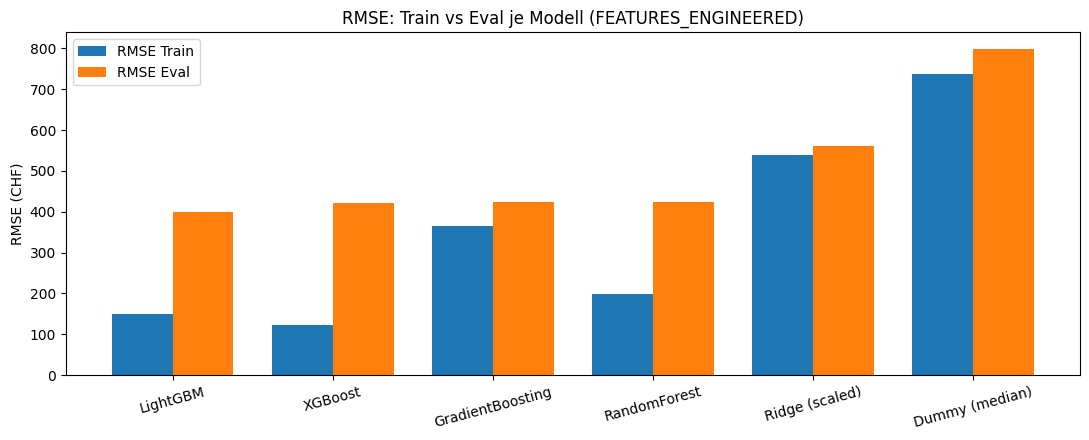

In [20]:
# Wir nehmen FEATURES_ENGINEERED als Hauptlauf, aber die Funktion ist generisch.
main_results = results_eng
main_fitted  = fitted_eng
main_cache   = cache_eng
main_features = FEATURES_ENGINEERED

models_sorted = main_results['Model'].tolist()
x_pos = np.arange(len(models_sorted))
width = 0.38

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.bar(x_pos - width/2, main_results['RMSE Train'], width, label='RMSE Train')
ax.bar(x_pos + width/2, main_results['RMSE Eval'],  width, label='RMSE Eval')
ax.set_xticks(x_pos)
ax.set_xticklabels(models_sorted, rotation=15)
ax.set_ylabel('RMSE (CHF)')
ax.set_title('RMSE: Train vs Eval je Modell (FEATURES_ENGINEERED)')
ax.legend()
plt.tight_layout()
plt.show()

## 12. Overfitting-Diagnose

In [21]:
def diagnose_overfitting(row):
    train_rmse = row['RMSE Train']
    eval_rmse  = row['RMSE Eval']
    r2_eval    = row['R² Eval']

    gap_ratio = eval_rmse / train_rmse if train_rmse > 0 else np.inf

    if gap_ratio > 1.5 and r2_eval > 0:
        return 'Possible overfitting'
    if r2_eval < 0.3:
        return 'Weak generalization / possible underfitting'
    if gap_ratio <= 1.25 and r2_eval >= 0.6:
        return 'Good generalization'
    return 'Check manually'


diag = main_results[['Model', 'RMSE Train', 'RMSE Eval', 'R² Eval', 'Overfitting Gap']].copy()
diag['Diagnose'] = main_results.apply(diagnose_overfitting, axis=1)
diag

,Model,RMSE Train,RMSE Eval,R² Eval,Overfitting Gap,Diagnose
0,LightGBM,150.286423,399.166141,0.743658,248.879718,Possible overfitting
1,XGBoost,121.598850,420.806889,0.715109,299.208039,Possible overfitting
2,GradientBoosting,364.777231,424.709516,0.709801,59.932284,Good generalization
3,RandomForest,198.916167,424.910709,0.709526,225.994542,Possible overfitting
4,Ridge (scaled),538.819616,560.072923,0.495337,21.253306,Check manually
5,Dummy (median),737.368884,799.089038,-0.027313,61.720154,Weak generalization / possible underfitting


## 13. Cross-Validation

5-fold KFold mit Shuffle (`random_state=42`). Mietwohnungen sind keine Zeitreihe, deshalb hier kein `TimeSeriesSplit`. Wir verwenden **die Pipeline**, damit Skalierung pro Falte sauber neu gefittet wird.

In [22]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def cv_scores(train_df, feature_cols, target_col, models, cv):
    X = train_df[feature_cols]
    y = train_df[target_col]

    records = []
    for name, model in models.items():
        cv_r2  = cross_val_score(model, X, y, cv=cv, scoring='r2')
        cv_mse = -cross_val_score(model, X, y, cv=cv, scoring='neg_mean_squared_error')
        records.append({
            'Model':       name,
            'CV R² mean':  cv_r2.mean(),
            'CV R² std':   cv_r2.std(),
            'CV RMSE mean': np.sqrt(cv_mse).mean(),
        })
    return pd.DataFrame(records).sort_values('CV R² mean', ascending=False).reset_index(drop=True)


cv_results = cv_scores(train_df, main_features, TARGET_COL, make_models(), cv)
cv_results

,Model,CV R² mean,CV R² std,CV RMSE mean
0,LightGBM,0.673731,0.009397,413.357575
1,XGBoost,0.665411,0.014220,418.608616
2,RandomForest,0.644675,0.020143,431.284596
3,GradientBoosting,0.635606,0.019850,436.590827
4,Ridge (scaled),0.439460,0.016385,541.744142
5,Dummy (median),-0.037457,0.010889,737.255590


## 14. Visualisierungen: Actual vs Predicted (bestes Modell)

Bestes Modell (nach RMSE Eval): LightGBM


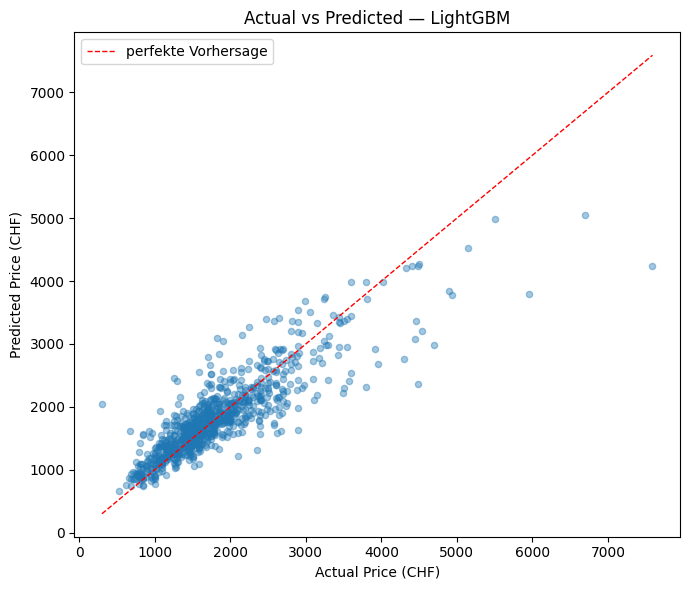

In [23]:
best_name  = main_results.iloc[0]['Model']
best_model = main_fitted[best_name]
y_eval     = eval_df[TARGET_COL]
y_pred     = main_cache[best_name]['eval']

print(f'Bestes Modell (nach RMSE Eval): {best_name}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_eval, y_pred, alpha=0.4, s=20)
lo = float(min(y_eval.min(), y_pred.min()))
hi = float(max(y_eval.max(), y_pred.max()))
ax.plot([lo, hi], [lo, hi], 'r--', linewidth=1, label='perfekte Vorhersage')
ax.set_xlabel('Actual Price (CHF)')
ax.set_ylabel('Predicted Price (CHF)')
ax.set_title(f'Actual vs Predicted — {best_name}')
ax.legend()
plt.tight_layout()
plt.show()

## 14b. Prediction Curves: Vergleich der Vorhersagekurven

Wir vergleichen mehrere Modelle direkt entlang **eines** Features. Da unser Modell mehrere Features nutzt, lässt sich keine echte 2D-Kurve plotten — stattdessen erzeugen wir eine **Partial-Prediction-Kurve**: ein Feature variiert über sein Wertebereich, alle anderen werden auf ihrem Median festgehalten.

In [24]:
def plot_prediction_curves(models, X_train, y_train, X_eval, y_eval, plot_feature):
    """Plottet Train/Eval-Punkte plus Partial-Prediction-Kurven mehrerer Modelle.

    - Train-Daten als blaue Punkte
    - Eval-Daten als orange X-Marker
    - Pro Modell eine Kurve über den Wertebereich von `plot_feature`,
      alle anderen Features werden auf ihrem Median festgehalten.
    """
    feature_grid = np.linspace(
        X_train[plot_feature].min(),
        X_train[plot_feature].max(),
        300,
    )

    median_values = X_train.median(numeric_only=True)
    X_curve = pd.DataFrame(
        np.tile(median_values.values, (len(feature_grid), 1)),
        columns=median_values.index,
    )
    # Spaltenreihenfolge muss exakt der Trainingsreihenfolge entsprechen
    X_curve = X_curve[X_train.columns]
    X_curve[plot_feature] = feature_grid

    plt.figure(figsize=(10, 6))

    plt.scatter(
        X_train[plot_feature], y_train,
        label='Train-Daten', alpha=0.5, s=20, color='tab:blue',
    )
    plt.scatter(
        X_eval[plot_feature], y_eval,
        label='Test-Daten', alpha=0.9, s=30, color='tab:orange', marker='x',
    )

    for model_name, model in models.items():
        y_curve = model.predict(X_curve)
        plt.plot(feature_grid, y_curve, label=model_name, linewidth=2)

    plt.title('Price Prediction: Vergleich der Vorhersagekurven')
    plt.xlabel(f'Feature: {plot_feature}')
    plt.ylabel('Preis (CHF)')
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Plot-Feature: area
Modelle in der Kurve: ['Ridge (scaled)', 'LightGBM', 'RandomForest']


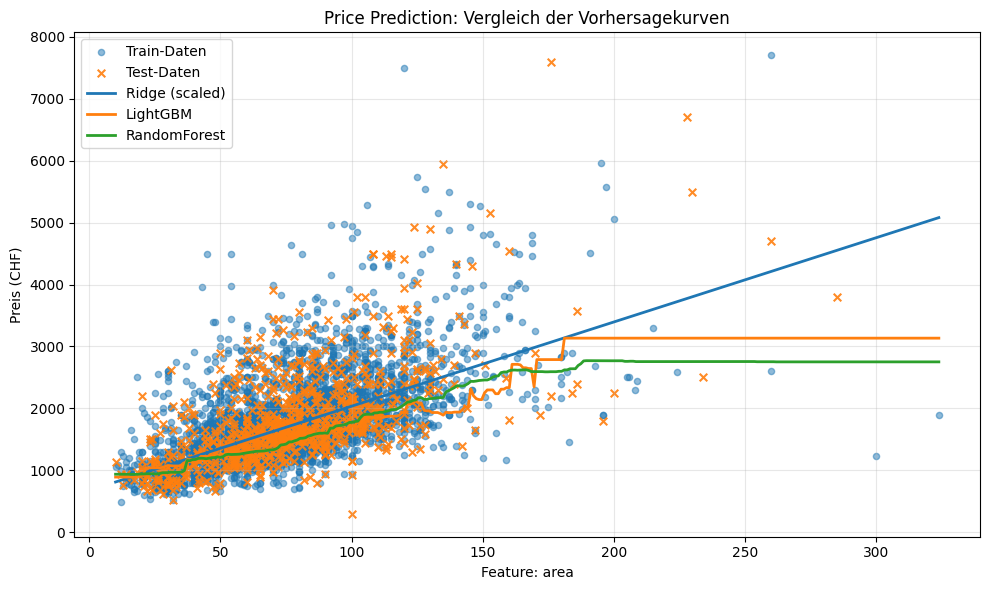

In [25]:
# Feature-Auswahl: 'area' bevorzugt, sonst das wichtigste numerische Feature
if 'area' in main_features:
    plot_feature = 'area'
else:
    plot_feature = main_features[0]
print(f'Plot-Feature: {plot_feature}')

# Wir wählen ein einfaches, ein "gutes" und ein komplexes Modell aus
# der bestehenden, bereits trainierten Sammlung.
_curve_candidates = ['Ridge (scaled)', 'GradientBoosting', 'RandomForest']
if HAS_LGBM and 'LightGBM' in main_fitted:
    _curve_candidates = ['Ridge (scaled)', 'LightGBM', 'RandomForest']

curve_models = {n: main_fitted[n] for n in _curve_candidates if n in main_fitted}
print('Modelle in der Kurve:', list(curve_models.keys()))

X_train_curve = train_df[main_features]
y_train_curve = train_df[TARGET_COL]
X_eval_curve  = eval_df[main_features]
y_eval_curve  = eval_df[TARGET_COL]

plot_prediction_curves(
    curve_models,
    X_train_curve, y_train_curve,
    X_eval_curve,  y_eval_curve,
    plot_feature,
)

**Wie liest man dieses Diagramm?**

Dieses Diagramm zeigt, wie sich die vorhergesagten Preise verändern, wenn sich ein ausgewähltes Feature verändert, während alle anderen Features konstant gehalten werden. Bei mehreren Features ist das **keine vollständige Darstellung des Modells**, sondern eine vereinfachte 2D-Sicht. Sie ist trotzdem nützlich, um Underfitting, Overfitting und unterschiedliche Modellverläufe sichtbar zu machen:

- Eine **flache, fast gerade** Kurve (z. B. Ridge) deutet auf ein lineares Modell hin, das nichtlineare Strukturen nicht abbilden kann → **Underfitting**.
- Eine **glatt geschwungene** Kurve, die der Punktwolke folgt → meist **gute Generalisierung**.
- Eine **stark zackige, übersensible** Kurve, die jeden einzelnen Punkt jagt → **Overfitting**.

## 14c. Demo: Underfitting / Good Fit / Overfitting mit Polynomial Regression

*Reines Lehrbeispiel auf synthetischen Daten — nicht Teil der finalen Modellbewertung.* Wir zeigen anhand einer einfachen 1D-Funktion, wie Modellkomplexität sich auf Bias und Varianz auswirkt:

- **Grad 1** (lineare Regression): zu einfach → Underfitting.
- **Grad 4**: passt sich der zugrunde liegenden Funktion sauber an → guter Trade-off.
- **Grad 15**: lernt das Rauschen mit, oszilliert wild zwischen den Trainingspunkten → Overfitting.

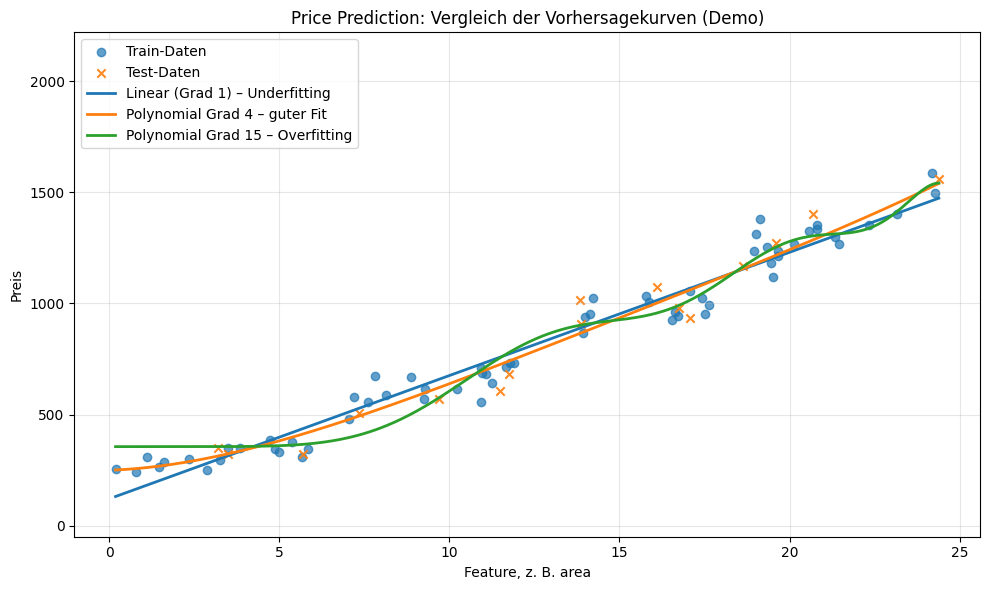

In [26]:
# === Didaktisches Demo: Polynomial Regression Grad 1 / 4 / 15 ===
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression as _LR
from sklearn.pipeline import make_pipeline

rng = np.random.default_rng(42)

# Synthetische Funktion: nicht-linear + Rauschen
def true_fn(x):
    return 200 + 30 * x + 50 * np.sin(x) + 5 * x ** 1.5

x_all = np.sort(rng.uniform(0, 25, size=80))
y_all = true_fn(x_all) + rng.normal(0, 60, size=x_all.size)

# 80/20 Split (synthetisch)
_split = int(0.8 * len(x_all))
_idx   = rng.permutation(len(x_all))
_tr, _ev = _idx[:_split], _idx[_split:]
x_tr, y_tr = x_all[_tr], y_all[_tr]
x_ev, y_ev = x_all[_ev], y_all[_ev]

x_grid = np.linspace(x_all.min(), x_all.max(), 400).reshape(-1, 1)

demo_models = {}
for label, deg in [('Linear (Grad 1) – Underfitting', 1),
                   ('Polynomial Grad 4 – guter Fit', 4),
                   ('Polynomial Grad 15 – Overfitting', 15)]:
    pipe = make_pipeline(PolynomialFeatures(deg, include_bias=False), _LR())
    pipe.fit(x_tr.reshape(-1, 1), y_tr)
    demo_models[label] = pipe

plt.figure(figsize=(10, 6))
plt.scatter(x_tr, y_tr, label='Train-Daten', alpha=0.7, color='tab:blue')
plt.scatter(x_ev, y_ev, label='Test-Daten', alpha=0.9, marker='x', color='tab:orange')

for label, pipe in demo_models.items():
    y_grid = pipe.predict(x_grid)
    plt.plot(x_grid, y_grid, label=label, linewidth=2)

plt.title('Price Prediction: Vergleich der Vorhersagekurven (Demo)')
plt.xlabel('Feature, z. B. area')
plt.ylabel('Preis')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
# y-Achse beschneiden, damit Grad-15-Schwingungen das Bild nicht sprengen
_lo = min(y_all.min(), -50)
_hi = max(y_all.max(), 50) * 1.4
plt.ylim(_lo, _hi)
plt.tight_layout()
plt.show()

## 15. Residual Analysis

Residuen = Actual − Predicted. Ideal: zufällig um 0 verteilt, glockenförmiges Histogramm, kein Trichter im Scatter.

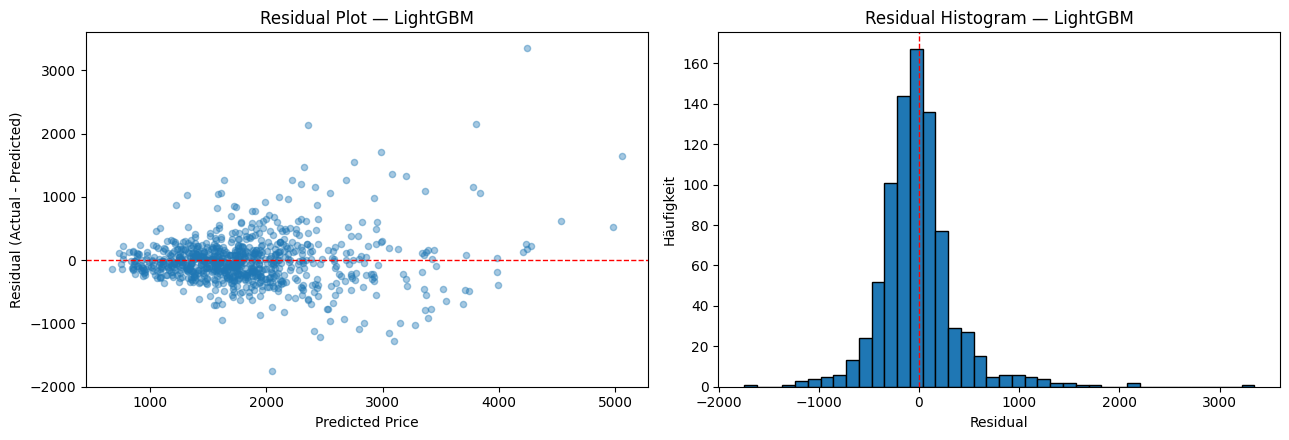

Residuen-Statistik:
count     840.000000
mean      -11.777749
std       399.230054
min     -1747.436976
25%      -216.738138
50%       -38.067641
75%       136.692419
max      3348.764303
Name: price, dtype: float64


In [27]:
residuals = y_eval - y_pred

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Scatter: Predicted vs Residuals
axes[0].scatter(y_pred, residuals, alpha=0.4, s=20)
axes[0].axhline(0, color='red', linestyle='--', linewidth=1)
axes[0].set_xlabel('Predicted Price')
axes[0].set_ylabel('Residual (Actual - Predicted)')
axes[0].set_title(f'Residual Plot — {best_name}')

# Histogramm
axes[1].hist(residuals, bins=40, edgecolor='black')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1)
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Häufigkeit')
axes[1].set_title(f'Residual Histogram — {best_name}')

plt.tight_layout()
plt.show()

print('Residuen-Statistik:')
print(residuals.describe())

## 16. Fehleranalyse nach Preisgruppen

Wir teilen den **tatsächlichen** Preis in 4 Quartile und schauen, in welchen Preisbändern das Modell besonders große Fehler hat.

In [28]:
eval_results = pd.DataFrame({
    'actual':    y_eval.reset_index(drop=True),
    'predicted': pd.Series(y_pred).reset_index(drop=True),
})
eval_results['error']     = eval_results['actual'] - eval_results['predicted']
eval_results['abs_error'] = eval_results['error'].abs()

eval_results['price_band'] = pd.qcut(
    eval_results['actual'], q=4,
    labels=['cheap', 'medium_low', 'medium_high', 'expensive'],
    duplicates='drop',
)

(
    eval_results
    .groupby('price_band')['abs_error']
    .agg(['count', 'mean', 'median', 'max'])
    .round(1)
)

,count,mean,median,max
price_band,,,,
cheap,211,215.8,150.4,1747.4
medium_low,212,176.1,143.0,970.4
medium_high,207,221.0,158.1,1276.0
expensive,210,445.3,311.5,3348.8


## 17. Feature Importance

Für Tree-/Boosting-Modelle: Modell-eigene Importance.  
Für Pipelines (z. B. Ridge): wir zeigen `coef_` falls vorhanden, sonst Permutation Importance als universellen Fallback.

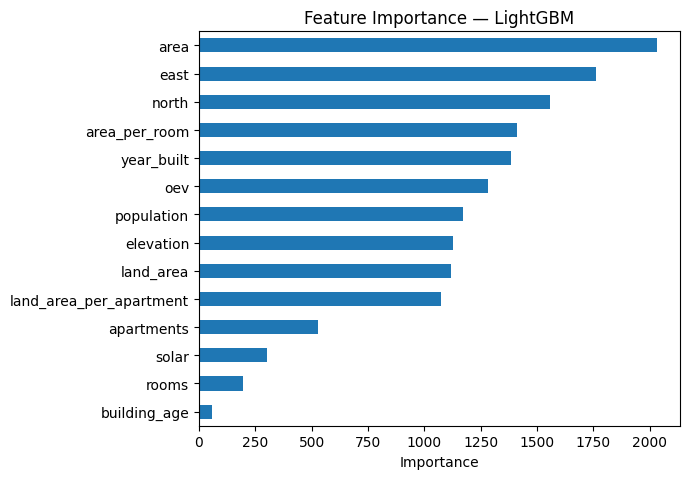

area                       2032
east                       1760
north                      1555
area_per_room              1409
year_built                 1384
oev                        1284
population                 1173
elevation                  1129
land_area                  1117
land_area_per_apartment    1074
apartments                  529
solar                       300
rooms                       194
building_age                 60
dtype: int32

In [29]:
def show_feature_importance(model, feature_cols, X_eval, y_eval, top_n=15):
    # 1) Tree-/Boosting-Modelle
    importances = getattr(model, 'feature_importances_', None)

    # 2) Pipeline → letzter Step
    if importances is None and isinstance(model, Pipeline):
        last = model.steps[-1][1]
        importances = getattr(last, 'feature_importances_', None)
        if importances is None and hasattr(last, 'coef_'):
            importances = np.abs(last.coef_)

    if importances is None:
        # 3) Permutation Importance als Fallback
        result = permutation_importance(
            model, X_eval, y_eval,
            n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
        )
        importances = result.importances_mean

    fi = (
        pd.Series(importances, index=feature_cols)
        .sort_values(ascending=True)
        .tail(top_n)
    )
    fig, ax = plt.subplots(figsize=(7, max(3, 0.35 * len(fi))))
    fi.plot(kind='barh', ax=ax)
    ax.set_title(f'Feature Importance — {best_name}')
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    return fi.iloc[::-1]


fi = show_feature_importance(
    best_model, main_features,
    eval_df[main_features], eval_df[TARGET_COL],
)
fi

## 18. Bestes Modell auswählen

Wir vergleichen die drei Feature-Sets über RMSE Eval und wählen die beste Kombination aus Feature-Set + Modell.

In [30]:
compare_runs = (
    pd.concat([
        results_small.assign(FeatureSet='SMALL'),
        results_all.assign(FeatureSet='ALL'),
        results_eng.assign(FeatureSet='ENGINEERED'),
    ])
    .sort_values('RMSE Eval')
    .reset_index(drop=True)
)

best_run = compare_runs.iloc[0]
print(f'Best run: FeatureSet={best_run["FeatureSet"]}, Model={best_run["Model"]}, RMSE Eval={best_run["RMSE Eval"]:.1f}')
compare_runs.head(10)

Best run: FeatureSet=ENGINEERED, Model=LightGBM, RMSE Eval=399.2


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap,FeatureSet
0,LightGBM,104.406305,264.420015,77.063275,178.589822,150.286423,399.166141,0.956946,0.743658,248.879718,ENGINEERED
1,LightGBM,113.217236,266.221322,84.050759,176.065715,164.153581,403.349280,0.948634,0.738257,239.195699,ALL
2,XGBoost,96.942429,266.688721,70.322693,173.267395,139.462017,407.013936,0.962925,0.733479,267.551918,ALL
3,RandomForest,125.550257,274.519146,83.924959,194.051235,201.437937,419.549506,0.922651,0.716809,218.111570,ALL
4,XGBoost,84.069862,269.927094,60.300720,183.716797,121.598850,420.806889,0.971814,0.715109,299.208039,ENGINEERED
5,GradientBoosting,254.019719,281.771860,181.709982,203.294542,364.777231,424.709516,0.746353,0.709801,59.932284,ENGINEERED
6,RandomForest,124.279534,276.874338,82.630503,192.508914,198.916167,424.910709,0.924575,0.709526,225.994542,ENGINEERED
7,GradientBoosting,254.786037,280.844423,181.992040,195.013427,368.144394,426.672542,0.741649,0.707112,58.528148,ALL
8,LightGBM,209.236569,359.495542,156.366338,253.147336,290.429385,528.252577,0.839211,0.551052,237.823192,SMALL
9,RandomForest,177.678407,364.053183,121.675301,265.190446,271.512203,528.530951,0.859475,0.550579,257.018747,SMALL


In [31]:
# Mapping FeatureSet -> Spaltenliste / fitted-Dict
_feature_set_lookup = {
    'SMALL':      (FEATURES_SMALL,      fitted_small),
    'ALL':        (FEATURES_ALL,        fitted_all),
    'ENGINEERED': (FEATURES_ENGINEERED, fitted_eng),
}
best_feature_cols, best_fitted_pool = _feature_set_lookup[best_run['FeatureSet']]
best_model_final = best_fitted_pool[best_run['Model']]

print(f'Bestes Modell: {best_run["Model"]}  |  Features: {best_run["FeatureSet"]}  ({len(best_feature_cols)} Spalten)')
print('Verwendete Features (in dieser Reihenfolge):')
print(best_feature_cols)

Bestes Modell: LightGBM  |  Features: ENGINEERED  (14 Spalten)
Verwendete Features (in dieser Reihenfolge):
['east', 'north', 'elevation', 'area', 'rooms', 'year_built', 'apartments', 'land_area', 'population', 'oev', 'solar', 'building_age', 'area_per_room', 'land_area_per_apartment']


## 19. Finale Prediction

Hier zwei Varianten:

1. **Refit auf gesamtem `df_model`** (Train + Eval) — für den Produktionseinsatz, wenn die Eval-Phase abgeschlossen ist.
2. **Spaltencheck** stellt sicher, dass das finale Test-DataFrame exakt die im Training verwendeten Features hat.

Wenn dein finales Test-Set unter einem anderen Variablennamen vorliegt (z. B. aus `model_v2.ipynb`), passe `final_test_df` entsprechend an.

In [32]:
def check_columns(final_test_df, required_cols):
    missing = set(required_cols) - set(final_test_df.columns)
    extras  = set(final_test_df.columns) - set(required_cols)
    print('Missing columns        :', sorted(missing))
    print('Extra columns (ignored):', sorted(extras))
    if missing:
        raise ValueError(f'Final test data is missing required columns: {missing}')


def fit_and_predict_final(df_model, final_test_df, feature_cols, target_col, model_factory):
    """Refit auf vollständige Modell-Daten und Predict auf finalem Testset."""
    check_columns(final_test_df, feature_cols)

    # Frische Modell-Instanz, damit kein "halb-trainierter" Zustand wiederverwendet wird.
    final_model = model_factory()
    final_model.fit(df_model[feature_cols], df_model[target_col])
    return final_model, final_model.predict(final_test_df[feature_cols])

In [33]:
# Demo: wir tun so, als wäre eval_df unser "finaler Testdatensatz".
# In der echten Anwendung wäre das ein separates Dataset (z. B. aus dem Hold-out
# in model_v2.ipynb, oder neue Wohnungen aus der Produktion).
final_test_df = eval_df.copy()

# model_factory: liefert exakt das Modell, das in 18 als bestes ausgewählt wurde.
_best_factory_lookup = {
    name: (lambda n=name: make_models()[n]) for name in make_models().keys()
}
model_factory = _best_factory_lookup[best_run['Model']]

# WICHTIG: Refit auf die volle Modell-Datenbasis nutzt train_df + eval_df,
# d. h. das, was in df_for_split steckt — nicht df (das enthält noch die
# Analyse-Spalte price_per_sqm).
df_full_for_refit = df_for_split

final_model_v3, final_predictions = fit_and_predict_final(
    df_full_for_refit, final_test_df,
    best_feature_cols, TARGET_COL, model_factory,
)

final_predictions[:10]

Missing columns        : []
Extra columns (ignored): ['price']


array([2342.36560333, 1118.41864669, 3033.82299894, 1386.33874102,
       2200.32411781, 1239.07440517, 3298.34603358, 1568.35651346,
       2219.37500645, 1416.77530514])

In [34]:
# Optional: Als DataFrame für Export
out_df = pd.DataFrame({
    'predicted_price': final_predictions,
})
if TARGET_COL in final_test_df.columns:
    out_df['actual_price'] = final_test_df[TARGET_COL].reset_index(drop=True)
    out_df['abs_error']    = (out_df['actual_price'] - out_df['predicted_price']).abs()
out_df.head()

,predicted_price,actual_price,abs_error
0,2342.365603,2400,57.634397
1,1118.418647,920,198.418647
2,3033.822999,3800,766.177001
3,1386.338741,1060,326.338741
4,2200.324118,2038,162.324118


## 20. Optional: Group Split nach Koordinaten

Ein normaler `train_test_split` kann Wohnungen aus *demselben Gebäude* oder direkt aus der Nachbarschaft sowohl in Train als auch in Eval landen lassen. Das macht das Eval optimistisch, weil das Modell quasi-bekannte Lagen sieht.

Mit einem **Group Split** prüfen wir die härtere Frage: *Wie gut generalisiert das Modell auf neue Orte, die es noch nie gesehen hat?* Dafür gruppieren wir auf gerundeten Koordinaten und stellen sicher, dass jede Gruppe entweder komplett in Train **oder** komplett in Eval landet.

In [35]:
if {'east', 'north'} <= set(df_for_split.columns):
    df_grp = df_for_split.copy()
    df_grp['location_group'] = (
        df_grp['east'].round(0).astype(int).astype(str) + '_' +
        df_grp['north'].round(0).astype(int).astype(str)
    )

    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    (train_idx, eval_idx), = gss.split(df_grp, groups=df_grp['location_group'])
    train_grp = df_grp.iloc[train_idx]
    eval_grp  = df_grp.iloc[eval_idx]

    print(f'Group-Split: Train={len(train_grp)}, Eval={len(eval_grp)}')
    print(f'Disjunkt? Schnittmenge der Gruppen: '
          f'{len(set(train_grp["location_group"]) & set(eval_grp["location_group"]))}')

    results_grp, _, _ = evaluate_models(
        train_grp, eval_grp, main_features, TARGET_COL, make_models(),
    )
    print('\nGroup-Split Resultate (sortiert nach RMSE Eval):')
    display(results_grp)
else:
    print('Spalten east/north fehlen — Group Split übersprungen.')

Group-Split: Train=3363, Eval=835
Disjunkt? Schnittmenge der Gruppen: 0

Group-Split Resultate (sortiert nach RMSE Eval):


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,XGBoost,91.122841,247.306580,64.277466,191.531616,134.224101,336.531469,0.968206,0.749852,202.307368
1,LightGBM,108.611055,254.671226,80.946773,203.907726,157.042651,345.824018,0.956477,0.735847,188.781367
2,RandomForest,129.576815,257.577424,84.016897,197.459396,209.434520,347.159730,0.922593,0.733802,137.725209
3,GradientBoosting,258.484549,261.510015,179.805545,207.735392,374.408205,355.870839,0.752613,0.720276,-18.537366
4,Ridge (scaled),390.680973,347.485519,282.741158,271.523764,560.311671,467.762634,0.445955,0.516723,-92.549038
5,Dummy (median),525.858460,506.056287,380.000000,390.000000,767.312723,686.943245,-0.039037,-0.042286,-80.369478


## 21. Geo-Analyse und Geo-Clustering

Geo-Daten können die Mietpreisvorhersage stark verbessern, weil **Lage** oft einer der wichtigsten Preisfaktoren ist. Reine Koordinaten kann das Modell direkt nutzen; **Geo-Cluster** als zusätzliches Feature helfen, regionale Preiszonen explizit zu kodieren – besonders bei Tree-/Boosting-Modellen.

**Wichtig (kein Leakage):** Der Clusterer wird ausschließlich auf `train_df` gefittet und dann auf `eval_df` *predicted*. Würden wir `fit_predict` auf der vollen Datenmenge laufen lassen, würden Eval-Beobachtungen in die Cluster-Definition einfließen und die Eval-Metriken künstlich aufblasen.

Falls `east`/`north` fehlen, wird die ganze Sektion automatisch übersprungen, ohne dass das Notebook crasht.

### 21.1 Geo-Spalten prüfen

In [36]:
GEO_COLS      = ['east', 'north']
ELEVATION_COL = 'elevation'

geo_cols_available = [c for c in GEO_COLS if c in df_for_split.columns]
has_full_geo       = len(geo_cols_available) == len(GEO_COLS)
has_elevation      = ELEVATION_COL in df_for_split.columns

print(f'Geo-Spalten verfügbar: {geo_cols_available}')
print(f'Elevation verfügbar : {has_elevation}')
print(f'Vollständige Geo-Daten: {has_full_geo}')

Geo-Spalten verfügbar: ['east', 'north']
Elevation verfügbar : True
Vollständige Geo-Daten: True


### 21.2 Geo-EDA

In [37]:
if has_full_geo:
    desc_cols = list(geo_cols_available)
    if has_elevation:
        desc_cols += [ELEVATION_COL]
    desc_cols += [TARGET_COL]
    print('Beschreibung der Geo- und Preis-Spalten:')
    display(df_for_split[desc_cols].describe().T)
else:
    print('Geo-EDA übersprungen — east/north fehlen.')

Beschreibung der Geo- und Preis-Spalten:


,count,mean,std,min,25%,50%,75%,max
east,4198.0,2.642086e+06,68867.424033,2494493.75,2.601377e+06,2648703.75,2.691348e+06,2818550.0
north,4198.0,1.219829e+06,51645.740197,1076962.00,1.181577e+06,1245427.75,1.258914e+06,1286728.5
elevation,4198.0,4.611092e+02,159.029291,197.70,3.902750e+02,434.85,5.131000e+02,1570.7
price,4198.0,1.826667e+03,737.658329,300.00,1.350000e+03,1685.00,2.145750e+03,7700.0


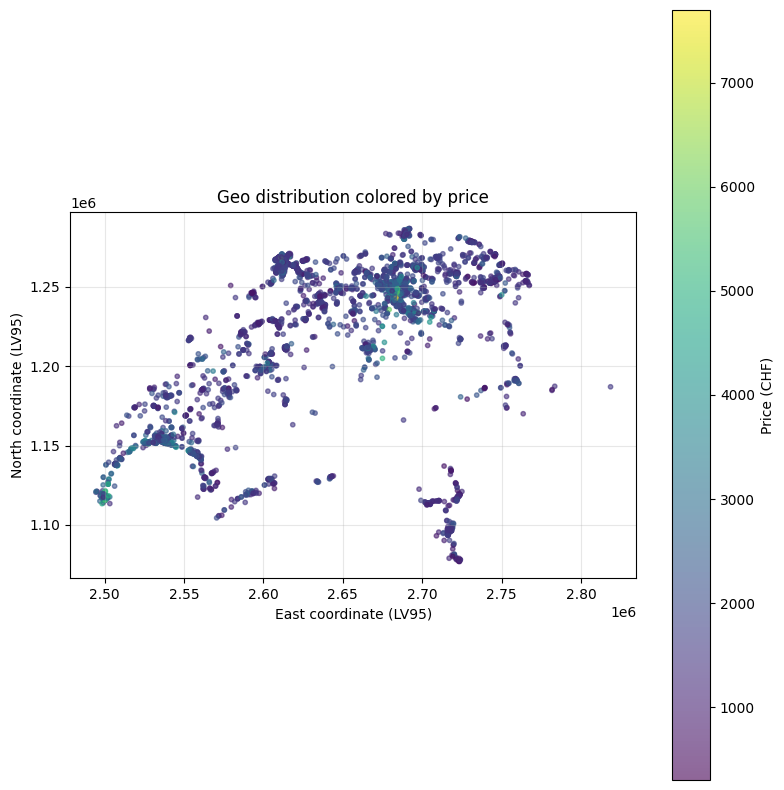

In [47]:
if has_full_geo:
    fig, ax = plt.subplots(figsize=(8, 8))  # quadratisch

    sc = ax.scatter(
        df_for_split['east'],
        df_for_split['north'],
        c=df_for_split[TARGET_COL],
        cmap='viridis',
        alpha=0.6,
        s=10
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Price (CHF)')

    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title('Geo distribution colored by price')

    ax.grid(True, alpha=0.3)

    # WICHTIG: echte quadratische Darstellung
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()


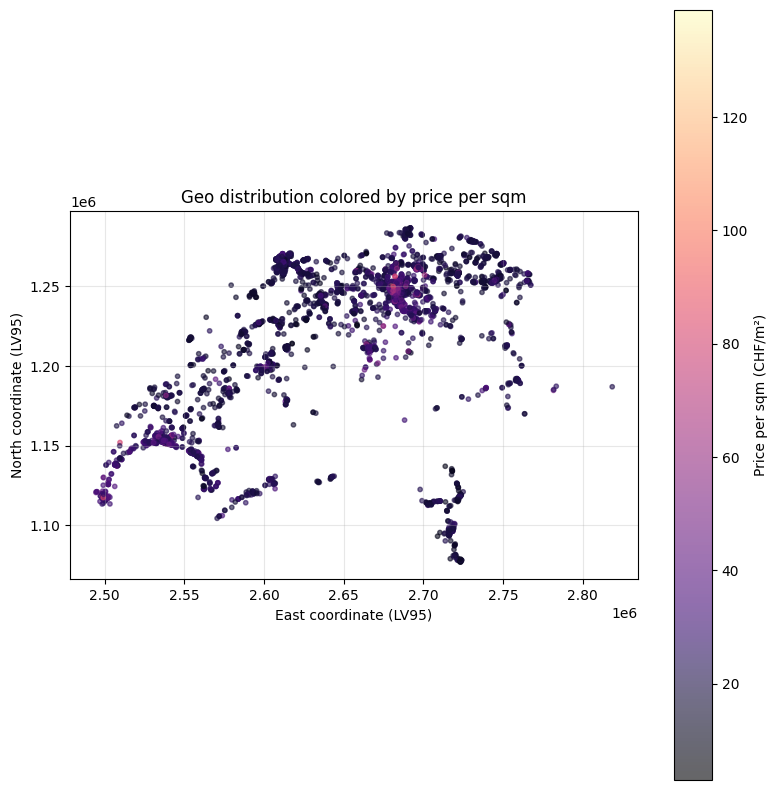

In [48]:
if has_full_geo and 'price_per_sqm' in df_clean.columns:
    fig, ax = plt.subplots(figsize=(8, 8))  # quadratisch

    sc = ax.scatter(
        df_clean['east'],
        df_clean['north'],
        c=df_clean['price_per_sqm'],
        cmap='magma',
        alpha=0.6,
        s=10
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Price per sqm (CHF/m²)')

    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title('Geo distribution colored by price per sqm')

    ax.grid(True, alpha=0.3)

    # WICHTIG: echte quadratische Darstellung
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()
else:
    print('Skipped: price_per_sqm nicht verfügbar oder Geo-Spalten fehlen.')


### 21.3 KMeans Clustering — verschiedene Clusterzahlen testen

Der Clusterer läuft in einer Pipeline mit `StandardScaler`, weil `east`/`north` (und ggf. `elevation`) sehr unterschiedliche Größenordnungen haben. **Gefittet wird nur auf `train_df`** – `predict` wird dann zusätzlich auf `eval_df` aufgerufen, ohne dass dessen Beobachtungen die Clusterzentren beeinflussen.

Für jeden Wert von `k` evaluieren wir kurz mit einem schnellen RandomForest, ob `geo_cluster` als Feature den RMSE auf Eval verbessert. Anschließend wählen wir das beste `k`.

In [40]:
from sklearn.cluster import KMeans

GEO_CLUSTER_COLS_2D = ['east', 'north']

if has_full_geo:
    cluster_counts = [4, 6, 8, 10, 12, 15]

    fast_models = {
        'RandomForest_fast': RandomForestRegressor(
            n_estimators=150, random_state=RANDOM_STATE, n_jobs=-1, min_samples_leaf=2,
        ),
    }

    cluster_search = []
    cluster_pipes  = {}

    for k in cluster_counts:
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('kmeans', KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)),
        ])
        pipe.fit(train_df[GEO_CLUSTER_COLS_2D])
        cluster_pipes[k] = pipe

        tr = train_df.assign(geo_cluster=pipe.predict(train_df[GEO_CLUSTER_COLS_2D]))
        ev = eval_df.assign(geo_cluster=pipe.predict(eval_df[GEO_CLUSTER_COLS_2D]))

        res, _, _ = evaluate_models(
            tr, ev, FEATURES_ALL + ['geo_cluster'], TARGET_COL, fast_models,
        )
        cluster_search.append({
            'k':         k,
            'RMSE Eval': res.iloc[0]['RMSE Eval'],
            'R² Eval':   res.iloc[0]['R² Eval'],
        })

    cluster_k_df = (
        pd.DataFrame(cluster_search)
          .sort_values('RMSE Eval')
          .reset_index(drop=True)
    )
    print('Cluster-Anzahl-Vergleich (RandomForest, FEATURES_ALL + geo_cluster):')
    display(cluster_k_df)

    best_k = int(cluster_k_df.iloc[0]['k'])
    print(f'\n→ Bestes k (auf Eval): {best_k}')
else:
    best_k = None
    print('Clustering übersprungen — Geo-Spalten fehlen.')

Cluster-Anzahl-Vergleich (RandomForest, FEATURES_ALL + geo_cluster):


,k,RMSE Eval,R² Eval
0,8,413.287666,0.725200
1,6,414.882764,0.723074
2,15,415.582661,0.722139
3,12,416.639230,0.720725
4,4,417.715879,0.719279
5,10,418.653774,0.718017



→ Bestes k (auf Eval): 8


### 21.4 Geo-Cluster visualisieren & Preisstatistik pro Cluster

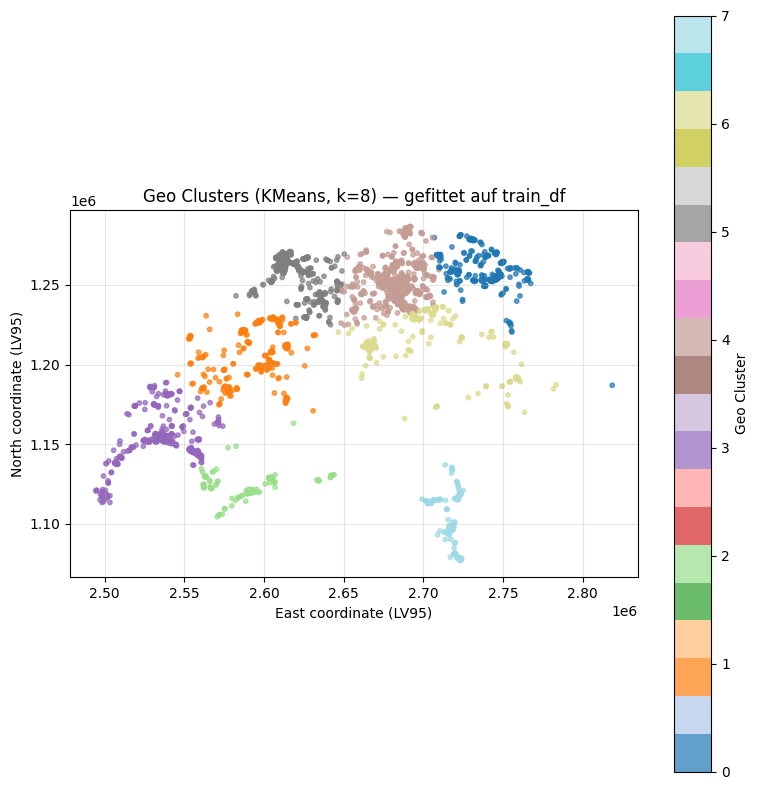

Preisstatistik pro Geo-Cluster (Train):


,count,mean,median,std
geo_cluster,,,,
4,894,2159.0,2029.0,786.0
3,565,2028.0,1800.0,876.0
6,237,1924.0,1830.0,680.0
5,716,1627.0,1572.0,528.0
2,102,1602.0,1500.0,597.0
1,293,1583.0,1530.0,460.0
0,384,1511.0,1450.0,492.0
7,167,1408.0,1330.0,466.0


In [49]:
if has_full_geo and best_k is not None:
    geo_pipe_2d = cluster_pipes[best_k]

    train_df_geo = train_df.copy()
    eval_df_geo  = eval_df.copy()

    train_df_geo['geo_cluster'] = geo_pipe_2d.predict(train_df[GEO_CLUSTER_COLS_2D])
    eval_df_geo['geo_cluster']  = geo_pipe_2d.predict(eval_df[GEO_CLUSTER_COLS_2D])

    fig, ax = plt.subplots(figsize=(8, 8))  # quadratisch

    sc = ax.scatter(
        train_df_geo['east'],
        train_df_geo['north'],
        c=train_df_geo['geo_cluster'],
        cmap='tab20',
        alpha=0.7,
        s=10
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Geo Cluster')

    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title(f'Geo Clusters (KMeans, k={best_k}) — gefittet auf train_df')

    ax.grid(True, alpha=0.3)

    # WICHTIG: echte metrische Darstellung
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()

    cluster_stats = (
        train_df_geo.groupby('geo_cluster')[TARGET_COL]
        .agg(['count', 'mean', 'median', 'std'])
        .round(0)
        .sort_values('mean', ascending=False)
    )

    print('Preisstatistik pro Geo-Cluster (Train):')
    display(cluster_stats)


### 21.5 Modellvergleich: ohne vs. mit Geo-Cluster

Wir vergleichen **fünf Feature-Sets** quer über alle Modelle:

1. `FEATURES_SMALL`
2. `FEATURES_ALL`
3. `FEATURES_ALL + ['geo_cluster']`
4. `FEATURES_ENGINEERED`
5. `FEATURES_ENGINEERED + ['geo_cluster']`

Die Tabelle ist nach `RMSE Eval` aufsteigend sortiert. Wenn die `+geo`-Varianten klar oben stehen, hilft das Cluster-Feature.

In [42]:
if has_full_geo and best_k is not None:
    feature_sets_geo = {
        'SMALL':          FEATURES_SMALL,
        'ALL':            FEATURES_ALL,
        'ALL+geo':        FEATURES_ALL + ['geo_cluster'],
        'ENGINEERED':     FEATURES_ENGINEERED,
        'ENGINEERED+geo': FEATURES_ENGINEERED + ['geo_cluster'],
    }

    geo_runs = []
    for set_name, feats in feature_sets_geo.items():
        # Validierung: alle Spalten in train_df_geo / eval_df_geo vorhanden?
        missing = [c for c in feats if c not in train_df_geo.columns]
        if missing:
            print(f'Skipped {set_name}: missing {missing}')
            continue

        results, _, _ = evaluate_models(
            train_df_geo, eval_df_geo, feats, TARGET_COL, make_models(),
        )
        results = results.assign(
            FeatureSet=set_name,
            n_geo_clusters=best_k if 'geo' in set_name else 0,
            geo_cluster_cols=', '.join(GEO_CLUSTER_COLS_2D) if 'geo' in set_name else '',
        )
        geo_runs.append(results)

    geo_results_df = (
        pd.concat(geo_runs)
        .sort_values('RMSE Eval')
        .reset_index(drop=True)
    )
    geo_results_df['Diagnose'] = geo_results_df.apply(diagnose_overfitting, axis=1)

    cols_to_show = [
        'FeatureSet', 'Model',
        'MAE Train', 'MAE Eval',
        'RMSE Train', 'RMSE Eval',
        'R² Train', 'R² Eval',
        'Overfitting Gap', 'Diagnose',
        'n_geo_clusters', 'geo_cluster_cols',
    ]
    display(geo_results_df[cols_to_show].head(15))
else:
    print('Modellvergleich übersprungen — Geo-Spalten fehlen.')

,FeatureSet,Model,MAE Train,MAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap,Diagnose,n_geo_clusters,geo_cluster_cols
0,ENGINEERED+geo,LightGBM,104.106127,265.017656,148.632283,395.356652,0.957889,0.748527,246.724369,Possible overfitting,8,"east, north"
1,ALL+geo,LightGBM,112.919106,264.721002,162.831986,397.848403,0.949458,0.745348,235.016417,Possible overfitting,8,"east, north"
2,ENGINEERED,LightGBM,104.406305,264.420015,150.286423,399.166141,0.956946,0.743658,248.879718,Possible overfitting,0,
3,ALL,LightGBM,113.217236,266.221322,164.153581,403.349280,0.948634,0.738257,239.195699,Possible overfitting,0,
4,ALL,XGBoost,96.942429,266.688721,139.462017,407.013936,0.962925,0.733479,267.551918,Possible overfitting,0,
5,ALL+geo,RandomForest,124.714897,273.709801,199.692919,414.693447,0.923985,0.723327,215.000529,Possible overfitting,8,"east, north"
6,ALL+geo,XGBoost,97.636948,269.622589,140.518675,417.280668,0.962361,0.719864,276.761993,Possible overfitting,8,"east, north"
7,ENGINEERED+geo,XGBoost,85.915131,267.561340,123.294351,418.444105,0.971022,0.718300,295.149753,Possible overfitting,8,"east, north"
8,ENGINEERED+geo,RandomForest,123.804368,275.576335,197.556061,419.068587,0.925603,0.717458,221.512526,Possible overfitting,8,"east, north"
9,ALL,RandomForest,125.550257,274.519146,201.437937,419.549506,0.922651,0.716809,218.111570,Possible overfitting,0,


### 21.6 Optional: Höhe (`elevation`) ins Clustering aufnehmen

Wenn `elevation` verfügbar ist, lohnt sich der Test, ob 3D-Clustering (`east`, `north`, `elevation`) bessere Cluster liefert als 2D. Das zwingende Argument für die Pipeline mit `StandardScaler`: Ohne Skalierung dominieren die Koordinaten (Größenordnung 10⁶) die Höhe (Größenordnung 10²) komplett.

In [43]:
if has_full_geo and has_elevation and best_k is not None:
    GEO_CLUSTER_COLS_3D = ['east', 'north', 'elevation']

    pipe_3d = Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)),
    ])
    pipe_3d.fit(train_df[GEO_CLUSTER_COLS_3D])

    train_df_geo3d = train_df.assign(geo_cluster=pipe_3d.predict(train_df[GEO_CLUSTER_COLS_3D]))
    eval_df_geo3d  = eval_df.assign(geo_cluster=pipe_3d.predict(eval_df[GEO_CLUSTER_COLS_3D]))

    res_3d, _, _ = evaluate_models(
        train_df_geo3d, eval_df_geo3d,
        FEATURES_ALL + ['geo_cluster'], TARGET_COL, make_models(),
    )
    res_3d = res_3d.assign(
        FeatureSet='ALL+geo',
        geo_cluster_cols=', '.join(GEO_CLUSTER_COLS_3D),
        n_geo_clusters=best_k,
    )
    print('Mit east/north/elevation als Cluster-Eingabe:')
    display(res_3d[['FeatureSet', 'Model', 'RMSE Eval', 'R² Eval', 'geo_cluster_cols']].head())
else:
    print('3D-Clustering übersprungen (elevation oder Geo-Spalten fehlen).')

Mit east/north/elevation als Cluster-Eingabe:


,FeatureSet,Model,RMSE Eval,R² Eval,geo_cluster_cols
0,ALL+geo,LightGBM,402.110035,0.739863,"east, north, elevation"
1,ALL+geo,XGBoost,410.722268,0.728601,"east, north, elevation"
2,ALL+geo,RandomForest,419.093469,0.717425,"east, north, elevation"
3,ALL+geo,GradientBoosting,429.439474,0.703301,"east, north, elevation"
4,ALL+geo,Ridge (scaled),557.958415,0.499140,"east, north, elevation"


### 21.7 Lineare Modelle: `geo_cluster` per OneHotEncoder

`geo_cluster` ist eigentlich eine **Kategorie**, auch wenn sie als Integer gespeichert ist. Für Tree-/Boosting-Modelle ist das egal – sie können numerische Splits machen. Ein lineares Modell wie Ridge interpretiert `geo_cluster=8` jedoch fälschlicherweise als "viermal so groß wie 2". Lösung: `ColumnTransformer` mit `OneHotEncoder` für die Cluster-Spalte und `StandardScaler` für die numerischen Features.

In [44]:
if has_full_geo and best_k is not None:
    from sklearn.compose      import ColumnTransformer
    from sklearn.preprocessing import OneHotEncoder

    feats_with_cluster = FEATURES_ALL + ['geo_cluster']
    numeric_features   = FEATURES_ALL
    cat_features       = ['geo_cluster']

    preprocessor = ColumnTransformer([
        ('num', StandardScaler(),                     numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features),
    ])

    ridge_geo_pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model',        Ridge(alpha=1.0, random_state=RANDOM_STATE)),
    ])

    res_ridge, _, _ = evaluate_models(
        train_df_geo, eval_df_geo, feats_with_cluster, TARGET_COL,
        {'Ridge (OneHot geo_cluster)': ridge_geo_pipe},
    )
    print('Ridge mit OneHotEncoded geo_cluster:')
    display(res_ridge)

Ridge mit OneHotEncoded geo_cluster:


,Model,MAE Train,MAE Eval,MedAE Train,MedAE Eval,RMSE Train,RMSE Eval,R² Train,R² Eval,Overfitting Gap
0,Ridge (OneHot geo_cluster),332.001652,337.432747,239.358759,235.275261,480.1135,491.783188,0.560598,0.610901,11.669687


### 21.8 Optional: DBSCAN — nur als Analysetool

DBSCAN findet **dichte Regionen** (Städte, Quartiere) und markiert isolierte Punkte als Noise (Cluster `-1`). Wir verwenden DBSCAN **nicht** als Modellfeature, weil es keine `predict()`-Methode hat: Für neue Eval-/Test-Punkte gibt es keinen sauberen Weg, dieselben Cluster zu vergeben. Hier nur zur Diagnostik.

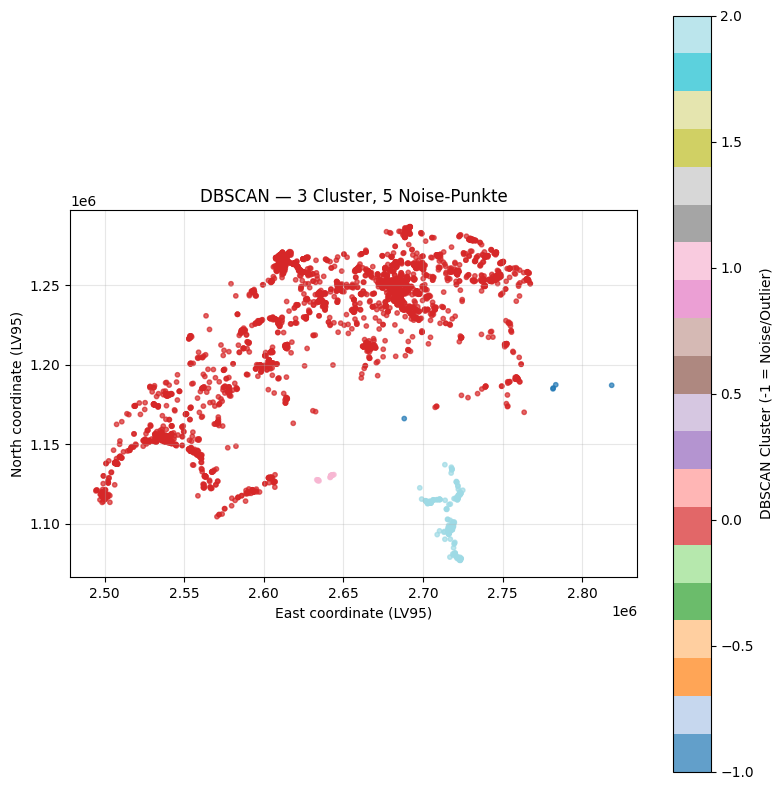

Cluster (ohne Noise): 3
Outlier (Cluster -1): 5


In [50]:
if has_full_geo:
    from sklearn.cluster import DBSCAN
    from sklearn.preprocessing import StandardScaler

    coords        = df_for_split[['east', 'north']]
    coords_scaled = StandardScaler().fit_transform(coords)

    dbscan        = DBSCAN(eps=0.3, min_samples=10)
    dbscan_labels = dbscan.fit_predict(coords_scaled)

    n_clusters_dbscan = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
    n_outliers        = (dbscan_labels == -1).sum()

    fig, ax = plt.subplots(figsize=(8, 8))  # quadratisch

    sc = ax.scatter(
        coords['east'], coords['north'],
        c=dbscan_labels,
        cmap='tab20',
        alpha=0.7,
        s=10
    )

    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('DBSCAN Cluster (-1 = Noise/Outlier)')

    ax.set_xlabel('East coordinate (LV95)')
    ax.set_ylabel('North coordinate (LV95)')
    ax.set_title(f'DBSCAN — {n_clusters_dbscan} Cluster, {n_outliers} Noise-Punkte')

    ax.grid(True, alpha=0.3)

    # WICHTIG: metrisch korrekt
    ax.set_aspect('equal', adjustable='box')

    plt.tight_layout()
    plt.show()

    print(f'Cluster (ohne Noise): {n_clusters_dbscan}')
    print(f'Outlier (Cluster -1): {n_outliers}')


### 21.9 Geo-Prediction-Kurve entlang `east`

Wir variieren `east` über seinen Wertebereich, halten alle anderen Features auf dem Median und plotten die Vorhersagekurve des besten Modells. Das ist eine **vereinfachte 2D-Sicht**: Echte Geo-Effekte sind zweidimensional (`east` × `north`) und können sich gegenseitig kompensieren – die Kurve zeigt nur den Effekt entlang einer Achse, mit `north` festgehalten.

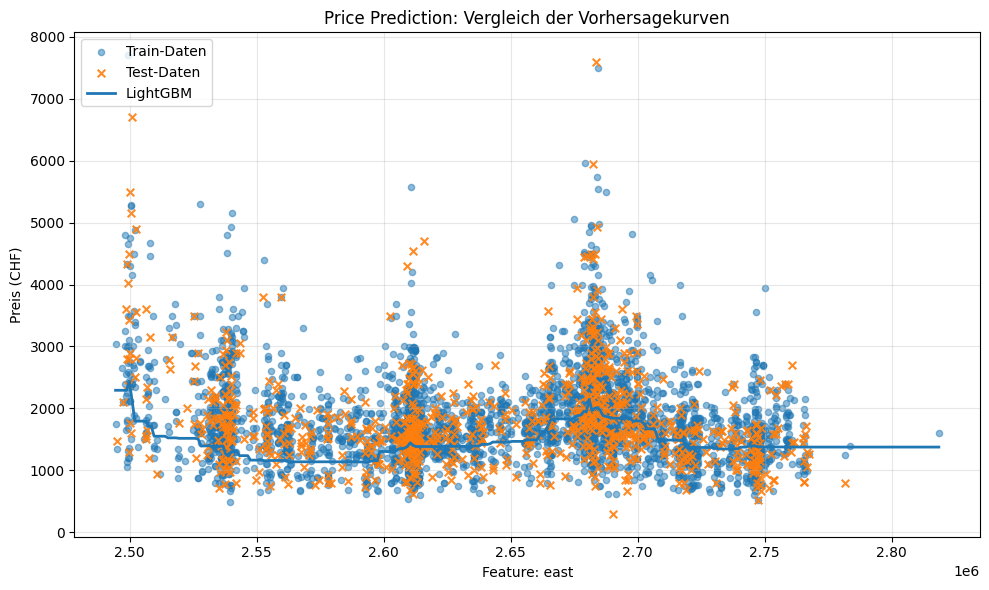

In [46]:
if has_full_geo and 'east' in main_features:
    geo_curve_model_name = best_name  # bereits in Kap. 14 gesetzt
    geo_curve_model      = main_fitted[geo_curve_model_name]

    plot_prediction_curves(
        {geo_curve_model_name: geo_curve_model},
        train_df[main_features], train_df[TARGET_COL],
        eval_df[main_features],  eval_df[TARGET_COL],
        plot_feature='east',
    )
else:
    print('Geo-Prediction-Kurve übersprungen — east nicht in main_features.')

### 21.10 Zusammenfassung Geo

Geo-Daten können die Mietpreisvorhersage stark verbessern, weil die Lage oft einer der wichtigsten Preisfaktoren ist. Reine Koordinaten können vom Modell direkt genutzt werden. Geo-Cluster können zusätzlich helfen, regionale Preiszonen zu bilden. Besonders bei Baum-Modellen kann ein Cluster-Feature nützlich sein. Man muss aber aufpassen, dass Cluster nicht auf Train und Eval gemeinsam gefittet werden, wenn sie als Modellfeature verwendet werden.

**Best-Practice-Checkliste aus diesem Kapitel:**

- KMeans ausschließlich auf `train_df` fitten, dann mit `predict` auf Eval anwenden.
- `StandardScaler` in der Cluster-Pipeline, weil `east`/`north`/`elevation` sehr unterschiedliche Größenordnungen haben.
- `geo_cluster` als Feature für Tree-Modelle direkt als Integer; für lineare Modelle via `OneHotEncoder` in einem `ColumnTransformer`.
- DBSCAN nur als Diagnose-Tool, nicht als Modellfeature (kein `predict` für neue Punkte).
- Für strengere Generalisierung: `GroupShuffleSplit` aus Kapitel 20 mit `location_group` aus gerundeten Koordinaten.

## Schluss & nächste Schritte

**Was sich gegenüber `model_v2.ipynb` verändert hat:**

- Genau **ein** sauberer Split (`train_df` / `eval_df`), kein `concat → head/tail`-Recovery.
- Kein `StandardScaler.fit_transform` auf kombinierten Train+Test-Daten (Leakage). Stattdessen Pipelines.
- Zentrale `FEATURES_*`-Listen — Training, Eval und Final Prediction nutzen exakt die gleichen Spalten in der gleichen Reihenfolge.
- `RMSE = np.sqrt(mean_squared_error(...))` — robust gegenüber sklearn-Versionen.
- `MedAE = median_absolute_error(...)` ohne fälschliches `np.sqrt(...)`.
- Optionale Boosting-Imports mit `try/except` — Notebook läuft auch ohne XGBoost/LightGBM.
- `errors='ignore'` nur an einer einzigen, klar dokumentierten Stelle (Removal der Analyse-Spalte) — nirgendwo, wo es Feature-Mismatches verstecken würde.
- Optionaler Group-Split nach Koordinaten als härteres Generalisierungs-Eval.

**Mögliche nächste Schritte**, falls du sie brauchst:

- Optuna-Tuning für das beste Modell (analog zur Tuning-Phase aus `model_v2.ipynb`).
- Log-Transformation des Targets (`np.log1p(price)`) — bei Mietpreisen oft hilfreich gegen die rechtsschiefe Verteilung.
- Stacking / Blending der besten 2–3 Modelle.
- Strukturierter Modell-Export per `joblib.dump`.